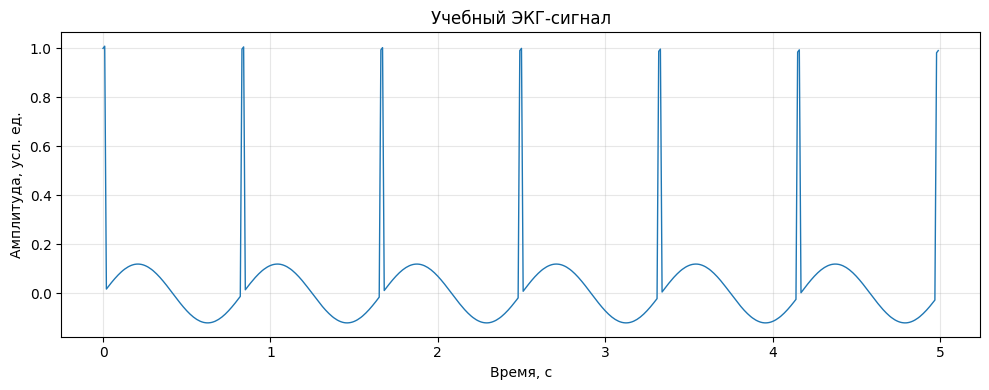

Контрольные вопросы:
1. Видны ли регулярные пики?
2. Есть ли выраженный шум?
3. Какие ограничения имеет визуальная оценка сигнала?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Практическое задание: визуализация учебного ЭКГ-сигнала.
# Студент строит график, описывает регулярность ритма, амплитуду и наличие шума.

file_path = "/content/ecg/ecg_sample_1_norm.csv"
data = pd.read_csv(file_path)

plt.figure(figsize=(10, 4))
plt.plot(data["time_sec"], data["signal"], linewidth=1)
plt.xlabel("Время, с")
plt.ylabel("Амплитуда, усл. ед.")
plt.title("Учебный ЭКГ-сигнал")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Контрольные вопросы:")
print("1. Видны ли регулярные пики?")
print("2. Есть ли выраженный шум?")
print("3. Какие ограничения имеет визуальная оценка сигнала?")

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Практическое задание: классификация учебных ЭКГ-признаков.
# Студент обучает простую модель и объясняет метрики качества.

data = pd.read_csv("/content/ecg/ecg_features_50.csv")
X = data.drop(columns=["sample_id", "label"])
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print("Отчёт классификации:")
print(classification_report(y_test, y_pred, target_names=["норма", "патология/аритмия"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Матрица ошибок:
[[8 0]
 [0 7]]
Отчёт классификации:
                   precision    recall  f1-score   support

            норма       1.00      1.00      1.00         8
патология/аритмия       1.00      1.00      1.00         7

         accuracy                           1.00        15
        macro avg       1.00      1.00      1.00        15
     weighted avg       1.00      1.00      1.00        15

ROC-AUC: 1.0


Dice coefficient: 0.74
IoU: 0.587


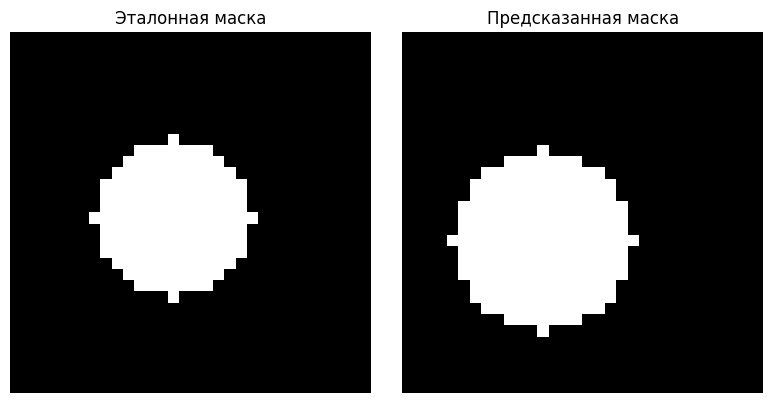

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Практическое задание: расчёт Dice и IoU для масок сегментации.

true_mask = pd.read_csv("/content/segmentation/mask_true_1.csv", header=None).values
pred_mask = pd.read_csv("/content/segmentation/mask_pred_1.csv", header=None).values

intersection = np.logical_and(true_mask == 1, pred_mask == 1).sum()
union = np.logical_or(true_mask == 1, pred_mask == 1).sum()

dice = 2 * intersection / ((true_mask == 1).sum() + (pred_mask == 1).sum())
iou = intersection / union

print("Dice coefficient:", round(dice, 3))
print("IoU:", round(iou, 3))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(true_mask, cmap="gray"); axes[0].set_title("Эталонная маска")
axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title("Предсказанная маска")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Практическое задание: минимальная retrieval-модель для поиска релевантных фрагментов.

docs = pd.read_csv("/content/nlp/emk_fragments_synthetic.csv")
query = "пациент с одышкой и снижением сатурации"

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs["text"])
q = vectorizer.transform([query])
scores = cosine_similarity(q, X).ravel()

docs["score"] = scores
print(docs.sort_values("score", ascending=False).head(3)[["doc_id", "text", "score"]])

   doc_id                                               text     score
3  doc_04  Пациент получает несколько лекарственных препа...  0.247212
0  doc_01  Пациент предъявляет жалобы на одышку при нагру...  0.225944
1  doc_02  На ЭКГ отмечается нерегулярный ритм; требуется...  0.000000


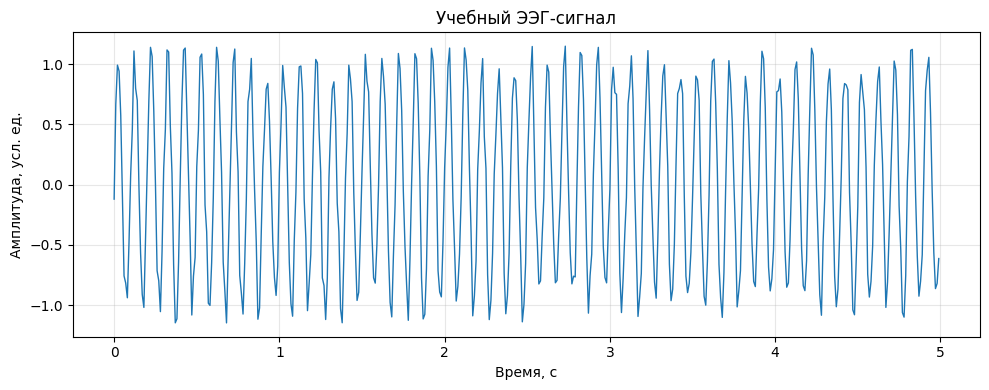

Контрольные вопросы:
1. Выглядит ли сигнал регулярным?
2. Есть ли участки, похожие на шум или артефакты?
3. Почему для анализа ЭЭГ важно качество записи?
4. Почему ИИ-модель для ЭЭГ должна проходить проверку на данных разных пациентов?


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Практическое задание: визуализировать учебный ЭЭГ-сигнал и описать его особенности.

file_path = "/content/eeg/eeg_sample_1_alpha.csv"
data = pd.read_csv(file_path)

plt.figure(figsize=(10, 4))
plt.plot(data["time_sec"], data["signal"], linewidth=1)
plt.xlabel("Время, с")
plt.ylabel("Амплитуда, усл. ед.")
plt.title("Учебный ЭЭГ-сигнал")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Контрольные вопросы:")
print("1. Выглядит ли сигнал регулярным?")
print("2. Есть ли участки, похожие на шум или артефакты?")
print("3. Почему для анализа ЭЭГ важно качество записи?")
print("4. Почему ИИ-модель для ЭЭГ должна проходить проверку на данных разных пациентов?")

In [6]:
import pandas as pd

# Практическое задание: простое учебное ранжирование молекул-кандидатов.
# Это не фармакологическая модель, а демонстрация логики вычислительного отбора.

file_path = "/content/molecules/molecules_demo.csv"
data = pd.read_csv(file_path)

print("Исходная таблица:")
print(data)

filtered = data[
    (data["activity_score"] >= 0.65) &
    (data["toxicity_risk"] <= 0.40) &
    (data["solubility_score"] >= 0.50)
].copy()

filtered["final_score"] = (
    0.5 * filtered["activity_score"] +
    0.3 * filtered["solubility_score"] -
    0.2 * filtered["toxicity_risk"]
)

filtered = filtered.sort_values("final_score", ascending=False)

print("Кандидаты после фильтрации и ранжирования:")
print(filtered[[
    "molecule_id", "smiles", "activity_score", "toxicity_risk",
    "solubility_score", "final_score"
]])

print("Контрольные вопросы:")
print("1. Какие молекулы прошли фильтр?")
print("2. Почему высокая активность недостаточна, если риск токсичности высокий?")
print("3. Что означает ADMET при разработке лекарств?")
print("4. Почему такой расчёт является только учебной моделью, а не доказательством эффективности препарата?")

Исходная таблица:
  molecule_id                         smiles  activity_score  toxicity_risk  \
0     MOL_001                            CCO            0.62           0.20   
1     MOL_002                      CCN(CC)CC            0.78           0.35   
2     MOL_003                    C1=CC=CC=C1            0.55           0.50   
3     MOL_004          CC(=O)Oc1ccccc1C(=O)O            0.82           0.30   
4     MOL_005   CN1C=NC2=C1C(=O)N(C)C(=O)N2C            0.70           0.25   
5     MOL_006  CC(C)CC1=CC=C(C=C1)C(C)C(=O)O            0.68           0.45   
6     MOL_007            CCOC(=O)C1=CC=CC=C1            0.74           0.38   
7     MOL_008                       C1CCCCC1            0.40           0.15   

   solubility_score  
0              0.80  
1              0.60  
2              0.40  
3              0.55  
4              0.65  
5              0.50  
6              0.58  
7              0.35  
Кандидаты после фильтрации и ранжирования:
  molecule_id                